Tutorial 4: Implement Simple Linear Regression


- Use the computers.csv dataset and perform the following activities:

Dataset contains the details of time taken to repair a computer, given the number of units to be repaired.

Dataset: Download from drive link

1. Build Regression model using Scikit-Learn Library(Model 3).
Set the 'Units' column as the input data or predictor column
Set the 'Minutes' column as the output data
Importing the required class -  LinearRegression
Creating a linear regression model
Fitting the model to the data
Fetching intercept and coefficient
2. Creating Linear Regression model with calculated coefficient and intercept.
3. Add the above model to the dataframe for Visualization.
4. Visualize Models using pyplot.
5. Compute the Coefficient of Determination to find accuracy.

In [341]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [342]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [343]:
computers = pd.read_csv('./Datasets/computers.csv')

In [344]:
computers

,Units,Minutes
0,1,23
1,2,29
2,3,49
3,4,64
4,4,74
5,5,87
6,6,96
7,6,97
8,7,109
9,8,119


In [345]:
computers.head()

,Units,Minutes
0,1,23
1,2,29
2,3,49
3,4,64
4,4,74


In [346]:
computers.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Units    14 non-null     int64
 1   Minutes  14 non-null     int64
dtypes: int64(2)
memory usage: 356.0 bytes


In [347]:
computers.isna().sum()

Units      0
Minutes    0
dtype: int64

In [348]:
mean_value = computers['Minutes'].mean()
mean_value

97.21428571428571

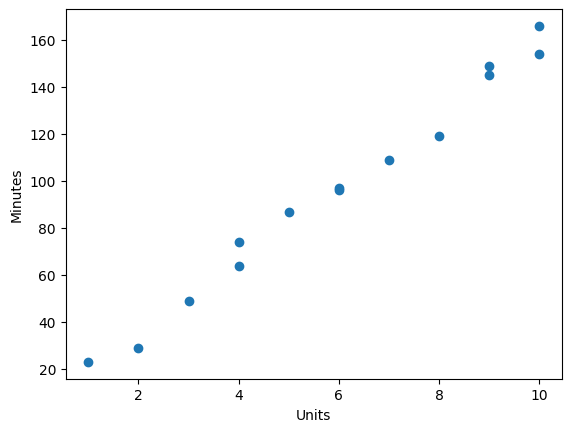

In [349]:
plt.scatter(x= computers['Units'], y= computers['Minutes'])
plt.xlabel('Units')
plt.ylabel('Minutes')
plt.show()

In [350]:
model0 = computers['Minutes'].mean()

In [351]:
model0

97.21428571428571

In [352]:
model1 = 10+15*computers['Units']

In [353]:
model1

0      25
1      40
2      55
3      70
4      70
5      85
6     100
7     100
8     115
9     130
10    145
11    145
12    160
13    160
Name: Units, dtype: int64

In [354]:
model2 = 6+12*computers['Units']

In [355]:
model2

0      18
1      30
2      42
3      54
4      54
5      66
6      78
7      78
8      90
9     102
10    114
11    114
12    126
13    126
Name: Units, dtype: int64

In [356]:
computers['model_0'] = model0
computers['model_1'] = model1
computers['model_2'] = model2

In [357]:
computers.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Units    14 non-null     int64  
 1   Minutes  14 non-null     int64  
 2   model_0  14 non-null     float64
 3   model_1  14 non-null     int64  
 4   model_2  14 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 692.0 bytes


In [358]:
computers

,Units,Minutes,model_0,model_1,model_2
0,1,23,97.214286,25,18
1,2,29,97.214286,40,30
2,3,49,97.214286,55,42
3,4,64,97.214286,70,54
4,4,74,97.214286,70,54
5,5,87,97.214286,85,66
6,6,96,97.214286,100,78
7,6,97,97.214286,100,78
8,7,109,97.214286,115,90
9,8,119,97.214286,130,102


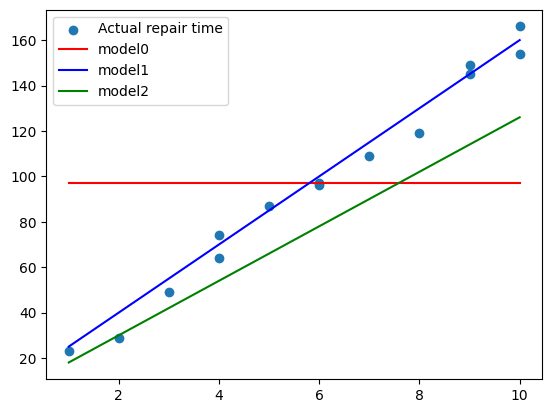

In [359]:
fig,ax = plt.subplots()
ax.scatter(x='Units', y='Minutes', data=computers, label='Actual repair time')
ax.plot(computers['Units'], computers['model_0'], color='red', label = 'model0')
ax.plot(computers['Units'], computers['model_1'], color='blue', label = 'model1')
ax.plot(computers['Units'], computers['model_2'], color='green', label = 'model2')
plt.legend()
plt.show()

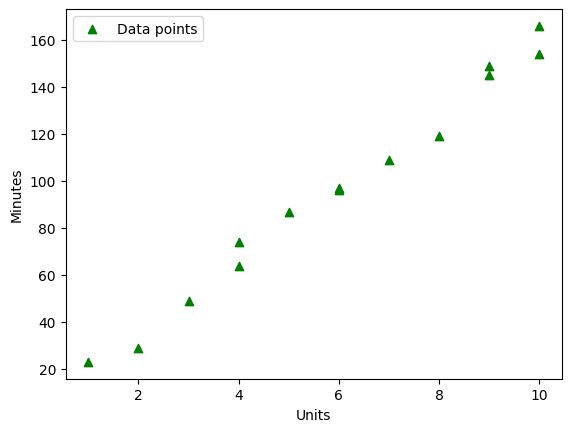

In [360]:
plt.scatter(computers['Units'], computers['Minutes'], color='green', label='Data points', marker='^')
plt.xlabel('Units')
plt.ylabel('Minutes')
plt.legend()
plt.show()

In [361]:
X = computers[['Units']]
y = computers['Minutes']

In [362]:
from sklearn.linear_model import LinearRegression
model3 = LinearRegression()
model3.fit(X,y)

LinearRegression()

In [363]:
print(f"Intercept: {model3.intercept_}")
print(f"Coefficient: {model3.coef_}")

Intercept: 4.161654135338296
Coefficient: [15.50877193]


In [364]:
Model_3 = 4.16 + 15.50 * computers['Units']
computers['model_3'] = model3.predict(computers[['Units']])
computers

,Units,Minutes,model_0,model_1,model_2,model_3
0,1,23,97.214286,25,18,19.670426
1,2,29,97.214286,40,30,35.179198
2,3,49,97.214286,55,42,50.687970
3,4,64,97.214286,70,54,66.196742
4,4,74,97.214286,70,54,66.196742
5,5,87,97.214286,85,66,81.705514
6,6,96,97.214286,100,78,97.214286
7,6,97,97.214286,100,78,97.214286
8,7,109,97.214286,115,90,112.723058
9,8,119,97.214286,130,102,128.231830


In [366]:
ax.plot(computers['Units'], computers['model_3'], color='orange', label = 'model3')
plt.show()

Tutorial 5: Multiple Linear Regression Model

In [367]:
rsq = model3.score(computers[['Units']], y) * 100
rsq

98.74371980620737

In [368]:
student = pd.read_csv('./Datasets/std_marks_data.csv')

In [369]:
student

,hours,age,internet,marks
0,6.84,15,0,78.64
1,6.56,20,1,88.80
2,NaN,21,1,88.90
3,8.67,22,1,98.99
4,7.55,17,1,92.34
...,...,...,...,...
295,2.99,25,0,43.45
296,6.55,15,1,77.74
297,0.00,20,1,75.76
298,9.90,22,0,99.99


In [370]:
student.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   hours     288 non-null    float64
 1   age       300 non-null    int64  
 2   internet  300 non-null    int64  
 3   marks     300 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 9.5 KB


In [371]:
student.isna().sum()

hours       12
age          0
internet     0
marks        0
dtype: int64

In [372]:
student['hours'] = pd.to_numeric(student['hours'], errors='coerce')
student['hours'] = student['hours'].fillna(student['hours'].mean())

In [373]:
X = student.iloc[:, :-1]
y = student.iloc[:, -1]

In [374]:
X.shape, y.shape

((300, 3), (300,))

In [375]:
X

,hours,age,internet
0,6.840000,15,0
1,6.560000,20,1
2,5.494514,21,1
3,8.670000,22,1
4,7.550000,17,1
...,...,...,...
295,2.990000,25,0
296,6.550000,15,1
297,0.000000,20,1
298,9.900000,22,0


In [376]:
y

0      78.64
1      88.80
2      88.90
3      98.99
4      92.34
       ...  
295    43.45
296    77.74
297    75.76
298    99.99
299    99.99
Name: marks, Length: 300, dtype: float64

In [377]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [378]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((240, 3), (60, 3), (240,), (60,))

In [379]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [380]:
model

LinearRegression()

In [381]:
model.fit(X_train, y_train)

LinearRegression()

In [382]:
model.intercept_

62.403770383977836

In [383]:
model.coef_

array([1.12562108, 0.17885318, 2.86204273])

In [384]:
y_pred = model.predict(X_test)

In [385]:
from sklearn.metrics import r2_score

In [386]:
r2_score(y_test, y_pred)

0.04539029325368027

In [387]:
print(f"Intercept: {model.intercept_}\nCoefficient: {model.coef_}")

Intercept: 62.403770383977836
Coefficient: [1.12562108 0.17885318 2.86204273]


In [388]:
hours = int(input("Enter hours of study: "))
age = int(input("Enter age: "))
internet = int(input('Enter internet use time: '))
data = [[hours, age, internet]]
print(f"Marks: {model.predict(data)}")

Marks: [90.97993599]


Exercise 3: Build Logistic Regression Model

Consider a coronary heart disease dataset (chd_data.csv) which lists the age in years ('age') and the presence/absence of evidence of significant coronary heart disease ('chd') for 100 patients.

The variable chd = 0 indicates the absence of coronary heart disease, whereas chd=1 indicates the presence of coronary heart disease.

- Import dataset and visualize the data to get an insight on building the model.
- Importing the required class
- Specifying the columns as predictor and target variable
- Split the data in training and test set in 70:30 ratio.
- Built model using sklearn.linear_model.LogisticRegression class.
- Train the model using the training data.
- Fetch the intercept and the coefficients of the model.
  Creating sample data.
- Predicting the probabilities for each of the class labels.
- Evaluate the model's performance on training and test data using 'accuracy' measure.

In [389]:
chd = pd.read_csv('./Datasets/chd_data.csv')

In [390]:
chd

,age,chd
0,20,0
1,23,0
2,24,0
3,25,1
4,25,0
...,...,...
95,63,1
96,64,1
97,64,0
98,65,1


In [391]:
chd.isna().sum()

age    0
chd    0
dtype: int64

In [392]:
chd.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     100 non-null    int64
 1   chd     100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


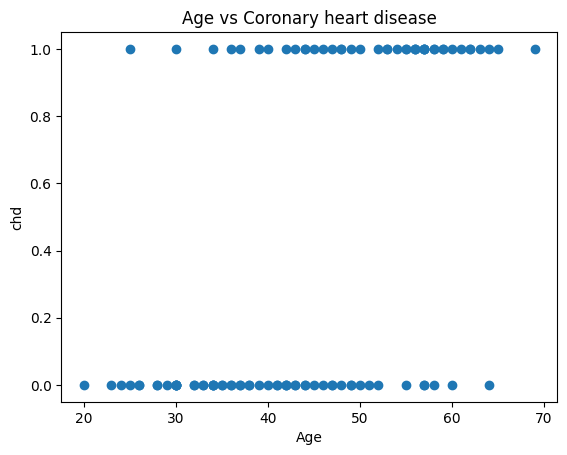

In [393]:
# Importing the required library

import matplotlib.pyplot as plt
# Plotting the 'chd' values against against 'age' values
plt.scatter("age", "chd", data = chd)
plt.xlabel("Age")
plt.ylabel("chd")
plt.title("Age vs Coronary heart disease")
plt.show()

In [394]:
predictor = chd['age']
target = chd['chd']

x = chd[["age"]]
y = chd[["chd"]]

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size= 0.3, random_state= 0)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (70, 1)
Shape of X_test: (30, 1)
Shape of y_train: (70, 1)
Shape of y_test: (30, 1)


In [395]:
# Importing required class
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model

LogisticRegression()

In [396]:
model.fit(X_train, y_train)

LogisticRegression()

In [397]:
print(f"Intercept: {model.intercept_}\nCoefficient: {model.coef_}")

Intercept: [-5.65118929]
Coefficient: [[0.11144281]]


In [398]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.7428571428571429
0.7333333333333333


In [399]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1], dtype=int64)

In [400]:
print(r2_score(y_test, y_pred))

-0.08597285067873317


In [401]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.92      0.63      0.75        19
           1       0.59      0.91      0.71        11

    accuracy                           0.73        30
   macro avg       0.76      0.77      0.73        30
weighted avg       0.80      0.73      0.74        30



In [402]:
print(confusion_matrix(y_pred, y_test))

[[12  7]
 [ 1 10]]


In [403]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy : 0.7333333333333333
Precision: 0.9090909090909091
Recall   : 0.5882352941176471
F1 Score : 0.7142857142857143
              precision    recall  f1-score   support

           0       0.63      0.92      0.75        13
           1       0.91      0.59      0.71        17

    accuracy                           0.73        30
   macro avg       0.77      0.76      0.73        30
weighted avg       0.79      0.73      0.73        30

